# Gaussian Process Regression

This demo shows how to use the class BayesUncertaintyOptimization along with GaussianProcessRegressor to regress the efficiency of three-jet events with MET < 50, while finding the optimal observation points that will reduce the uncertainty of the GP model. 
We consider the following nuisance parameters:
- nu_J: jet energy scale of the leading jet, j1
- nu_j: jet energy scale of the two softer jets, j2 & j3

And the following selection criteria:
- (j1_pT/nu_J > 200 GeV) & (j2_pT/nu_j < 200 GeV)
- MET < 50 GeV

The functions used to calculate the efficiency and MET can be found in obj_functions.py  
Derivative information is used to improve the regression results. 

In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import h5py
from multiprocessing import Pool, cpu_count
from sklearn.metrics import mean_squared_error

sys.path.append("../../../gpder")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware
from gpder.gaussian_process.warpers import GPWarper
from gpder.bayes import BayesUncertaintyOptimization

from obj_functions import eff_MET50  # Efficiency function
from obj_functions import deff_MET50_sigmoid  # Gradient of eff_MET50 wrt nuJ
from plotting_utils import plot_gp, plot_mse_uncert, plot_gp_evolution

The s parameter controls the spread of the sigmoids used to compute the gradients. 
Larger s (s>1) will result in smoother sigmoids while smaller s (s<1) will result in steeper sigmoids.

In this demo, we use smooth sigmoids to avoid discontinuities in the gradients.

In [2]:
# use multicore processing to speed up run time when generating test set.
def eff_MET50_multi(args):
    (nuJ1, nuJ23) = args
    return eff_MET50(nuJ1, nuJ23)

def deff_MET50_sigmoid_smooth(nuJ1, nuJ23):
    return deff_MET50_sigmoid(nuJ1, nuJ23, s=10)

def deff_MET50_sigmoid_multi(args):
    (nuJ1, nuJ23) = args
    return deff_MET50_sigmoid_smooth(nuJ1, nuJ23)

In [3]:
# -- testing points -- # 
res = 25
X_lower = 0.5
X_upper = 1.5
# lin = np.linspace(X_lower, X_upper, res)
# nu_J_test, nu_j_test = np.meshgrid(lin, lin)
# X_test = np.vstack((nu_J_test.flatten(), nu_j_test.flatten())).T 
# y_test = Pool(cpu_count()).map(eff_MET50_multi, X_test)
# y_test = np.array(y_test).reshape(-1, 1)
# dX_test = X_test
# dy_test = Pool(cpu_count()).map(deff_MET50_sigmoid_multi, X_test)
# dy_test = np.array(dy_test)

f = h5py.File("./dataset_25res.h5", 'r')
X_test = np.array(f['X'])
y_test = np.array(f['y'])
dy_test = np.array(f['dy'])
f.close()

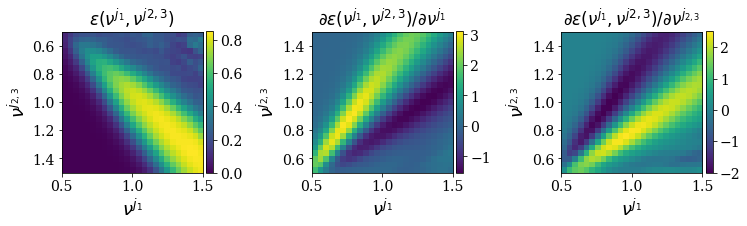

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "14"

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(wspace=0.47)

subplots_titles=[r'$\epsilon(\nu^{j_1}, \nu^{j2,3})$',
                 r"${\partial\epsilon(\nu^{j_1}, \nu^{j2,3})} / {\partial \nu^{j_1}}$", 
                 r"${\partial\epsilon(\nu^{j_1}, \nu^{j2,3})} / {\partial \nu^{j_{2,3}}}$"]

im = ax[0].imshow(y_test.reshape(res, res), 
                  origin='upper', 
                  extent=[X_lower, X_upper, X_upper, X_lower])
cbar = fig.colorbar(im, ax=ax[0], shrink=0.65, pad=0.02)
ax[0].set_title(subplots_titles[0])
ax[0].set_xlabel(r'$\nu^{j_1}$', fontsize=18)
ax[0].set_ylabel(r'$\nu^{j_{2,3}}$', fontsize=18)
ax[0].tick_params(axis='both', which='major')

n = len(X_test)
for i in [1, 2]:    
    im = ax[i].imshow(dy_test[:, i-1].reshape(res, res), 
                      origin='lower', 
                      extent=[X_lower, X_upper, X_lower, X_upper])
    cbar = fig.colorbar(im, ax=ax[i], shrink=0.65, pad=0.02)
    ax[i].set_title(subplots_titles[i])
    ax[i].set_xlabel(r'$\nu^{j_1}$', fontsize=18)
    ax[i].set_ylabel(r'$\nu^{j_{2,3}}$', fontsize=18)
    ax[i].tick_params(axis='both', which='major')
plt.show()
    

## BED with regular GP 

In [5]:
# -- training points -- # 
nu_J_train = [0.7, 1.0, 1.0, 1.0, 1.3]
nu_j_train = [1.0, 0.7, 1.0, 1.3, 1.0]
X_train = np.vstack((nu_J_train, nu_j_train)).T
y_train = Pool(cpu_count()).map(eff_MET50_multi, X_train)
y_train = np.array(y_train).reshape(-1, 1)
dX_train = X_train
dy_train = Pool(cpu_count()).map(deff_MET50_sigmoid_multi, X_train)
dy_train = np.array(dy_train)

In [6]:
kernel = GPKernel(constant_value=0.1,
                  length_scale=0.2,
                  noise_level=1e-3)
gp_reg = GaussianProcessRegressor(kernel=kernel,
                                  optimizer=None,
                                  random_state=123)
gp_reg.fit(X_train, y_train)
print("Kernel: ", gp_reg.kernel_)

params_dicc = {'nuJ1': (X_lower, X_upper), 'nuJ23': (X_lower, X_upper)}
bayes_reg = BayesUncertaintyOptimization(
    fun=eff_MET50,                   # Function to minimize the uncertainty of
    gp=gp_reg,                       # GPR used in the search
    verbose=True,                    # If True, a print-out is printed at every iteration
    param_bounds=params_dicc,        # dicc={'param_name': (lower_bound, upper_bound)}
    random_state=123,                # Random state seed
    )

bayes_reg.minimize_uncertainty(
    X_init=X_train, y_init=y_train,
    X_query=X_test,
    acquisition_opt='trace',
    n_iters=5,                # No. of bayes_regian iterations
    n_minimizer_restarts=20,   # No. of times to restart the minimizer
    )

Kernel:  0.1 * RBF(length_scale=0.2) + WhiteKernel(noise_level=0.001)
| Iter | nuJ1      | nuJ23     | Target     |
| 0    | 0.700000  | 1.000000  | 0.037429   |
| 0    | 1.000000  | 0.700000  | 0.276012   |
| 0    | 1.000000  | 1.000000  | 0.772925   |
| 0    | 1.000000  | 1.300000  | 0.187620   |
| 0    | 1.300000  | 1.000000  | 0.521978   |
| 1    | 1.343550  | 1.343550  | 0.835987   |
| 2    | 0.656382  | 0.656382  | 0.411837   |
| 3    | 1.348484  | 0.651513  | 0.200000   |
| 4    | 0.651519  | 1.348478  | 0.000184   |
| 5    | 1.441434  | 1.077046  | 0.446785   |


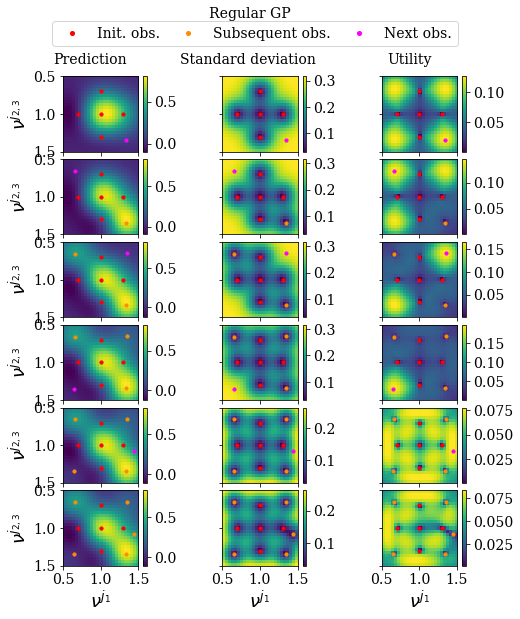

In [7]:
plot_gp_evolution(bayes_reg, 5, X_test)

## BED with derivative GP 

In [8]:
kernel = GPKernelDerAware(constant_value=0.1,
                          length_scale=0.2,
                          noise_level=1e-3,
                          noise_level_dX=1e-1)
gp_der = GaussianProcessRegressor(kernel=kernel,
                                  optimizer=None,
                                  random_state=123)
gp_der.fit(X_train, y_train, dX_train, dy_train)
print("Kernel: ", gp_der.kernel_)

params_dicc = {'nuJ1': (X_lower, X_upper), 'nuJ23': (X_lower, X_upper)}
bayes_der = BayesUncertaintyOptimization(
    fun=eff_MET50,                   # Function to minimize the uncertainty of
    dfun=deff_MET50_sigmoid_smooth,  # Function to minimize the uncertainty of
    gp=gp_der,                       # GPR used in the search
    verbose=True,                    # If True, a print-out is printed at every iteration
    param_bounds=params_dicc,        # dicc={'param_name': (lower_bound, upper_bound)}
    random_state=123,                # Random state seed
    )

bayes_der.minimize_uncertainty(
    X_init=X_train, y_init=y_train,
    dX_init=dX_train, dy_init=dy_train,
    X_query=X_test,
    acquisition_opt='trace',
    n_iters=5,                # No. of bayes_regian iterations
    n_minimizer_restarts=20,   # No. of times to restart the minimizer
    )

Kernel:  0.1 * DerivativeRBF(length_scale=0.2) + WhiteKernel_X(noise_level=0.001) + WhiteKernel_dX(noise_level=0.1)
| Iter | nuJ1      | nuJ23     | Target     |
| 0    | 0.700000  | 1.000000  | 0.037429   |
| 0    | 1.000000  | 0.700000  | 0.276012   |
| 0    | 1.000000  | 1.000000  | 0.772925   |
| 0    | 1.000000  | 1.300000  | 0.187620   |
| 0    | 1.300000  | 1.000000  | 0.521978   |
| 1    | 1.356827  | 1.356827  | 0.836224   |
| 2    | 0.640889  | 0.640889  | 0.387496   |
| 3    | 1.376086  | 0.623827  | 0.129032   |
| 4    | 0.623394  | 1.376543  | 0.000073   |
| 5    | 0.517542  | 0.999795  | 0.000481   |


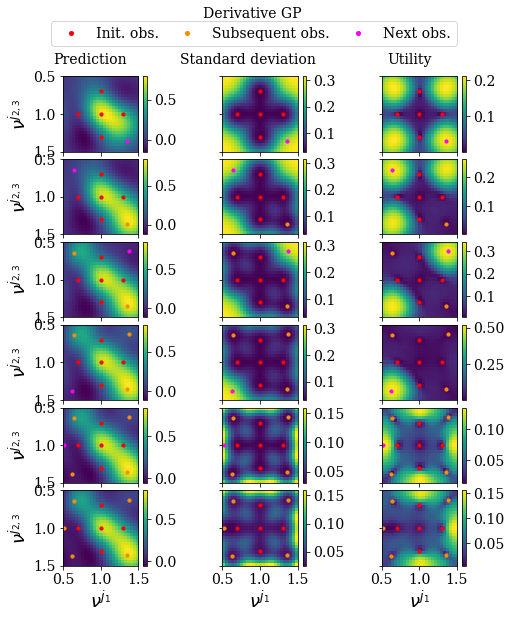

In [9]:
plot_gp_evolution(bayes_der, 5, X_test)